In [99]:
import pandas as pd
import numpy as np
data = pd.read_csv('world_data.csv')

In [100]:
data.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [101]:
#dropping unnecessary columns
data = data.drop(['Abbreviation','Latitude','Longitude','Official language','Largest city','Currency-Code','Capital/Major City','Calling Code'],axis=1)

In [102]:
data.dtypes

Country                                       object
Density\n(P/Km2)                              object
Agricultural Land( %)                         object
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                                object
Fertility Rate                               float64
Forested Area (%)                             object
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)        object
Gross tertiary education enrollment (%)       object
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                  

In [103]:
data.head()

,Country,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,60,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,4.47,...,638.0,$0.43,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,105,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,1.62,...,15.0,$1.12,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,18,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,3.02,...,112.0,$0.95,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,164,40.00%,468,NaN,7.20,469,NaN,NaN,1.27,...,NaN,$6.63,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,26,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,5.52,...,241.0,$0.71,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"


In [104]:
data.columns

Index(['Country', 'Density\n(P/Km2)', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Co2-Emissions',
       'CPI', 'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Life expectancy', 'Maternal mortality ratio', 'Minimum wage',
       'Out of pocket health expenditure', 'Physicians per thousand',
       'Population', 'Population: Labor force participation (%)',
       'Tax revenue (%)', 'Total tax rate', 'Unemployment rate',
       'Urban_population'],
      dtype='object')

In [105]:
percentage_cols = ['Agricultural Land( %)','CPI Change (%)','Out of pocket health expenditure','Population: Labor force participation (%)','Tax revenue (%)','Total tax rate','Unemployment rate']
#code to remove % sign and convert to float
for col in percentage_cols:
    data[col] = data[col].str.rstrip('%').astype('float')
data.dtypes

Country                                       object
Density\n(P/Km2)                              object
Agricultural Land( %)                        float64
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                             object
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)        object
Gross tertiary education enrollment (%)       object
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                  

In [106]:
#Seeing all the object columns 
object_cols = data.select_dtypes(include=['object']).columns
object_cols

Index(['Country', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Armed Forces size',
       'Co2-Emissions', 'CPI', 'Forested Area (%)', 'Gasoline Price', 'GDP',
       'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Minimum wage', 'Population',
       'Urban_population'],
      dtype='object')

In [107]:
data[object_cols].head()

,Country,Density\n(P/Km2),Land Area(Km2),Armed Forces size,Co2-Emissions,CPI,Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Minimum wage,Population,Urban_population
0,Afghanistan,60,"652,230","323,000","8,672",149.9,2.10%,$0.70,"$19,101,353,833",104.00%,9.70%,$0.43,"38,041,754","9,797,273"
1,Albania,105,"28,748","9,000","4,536",119.05,28.10%,$1.36,"$15,278,077,447",107.00%,55.00%,$1.12,"2,854,191","1,747,593"
2,Algeria,18,"2,381,741","317,000","150,006",151.36,0.80%,$0.28,"$169,988,236,398",109.90%,51.40%,$0.95,"43,053,054","31,510,100"
3,Andorra,164,468,NaN,469,NaN,34.00%,$1.51,"$3,154,057,987",106.40%,NaN,$6.63,"77,142","67,873"
4,Angola,26,"1,246,700","117,000","34,693",261.73,46.30%,$0.97,"$94,635,415,870",113.50%,9.30%,$0.71,"31,825,295","21,061,025"


In [108]:
percentage_cols = ['Forested Area (%)','Gross primary education enrollment (%)','Gross tertiary education enrollment (%)',]
#code to remove % sign and convert to float
for col in percentage_cols:
    data[col] = data[col].str.rstrip('%').astype('float')
data.dtypes

Country                                       object
Density\n(P/Km2)                              object
Agricultural Land( %)                        float64
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                  

In [109]:
data.isnull().sum().sort_values(ascending=False)

Minimum wage                                 45
Tax revenue (%)                              26
Armed Forces size                            24
Gasoline Price                               20
Unemployment rate                            19
Population: Labor force participation (%)    19
CPI                                          17
CPI Change (%)                               16
Maternal mortality ratio                     14
Gross tertiary education enrollment (%)      12
Total tax rate                               12
Life expectancy                               8
Gross primary education enrollment (%)        7
Out of pocket health expenditure              7
Forested Area (%)                             7
Fertility Rate                                7
Co2-Emissions                                 7
Agricultural Land( %)                         7
Physicians per thousand                       7
Infant mortality                              6
Birth Rate                              

In [110]:
data[object_cols].head()

,Country,Density\n(P/Km2),Land Area(Km2),Armed Forces size,Co2-Emissions,CPI,Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Minimum wage,Population,Urban_population
0,Afghanistan,60,"652,230","323,000","8,672",149.9,2.1,$0.70,"$19,101,353,833",104.0,9.7,$0.43,"38,041,754","9,797,273"
1,Albania,105,"28,748","9,000","4,536",119.05,28.1,$1.36,"$15,278,077,447",107.0,55.0,$1.12,"2,854,191","1,747,593"
2,Algeria,18,"2,381,741","317,000","150,006",151.36,0.8,$0.28,"$169,988,236,398",109.9,51.4,$0.95,"43,053,054","31,510,100"
3,Andorra,164,468,NaN,469,NaN,34.0,$1.51,"$3,154,057,987",106.4,NaN,$6.63,"77,142","67,873"
4,Angola,26,"1,246,700","117,000","34,693",261.73,46.3,$0.97,"$94,635,415,870",113.5,9.3,$0.71,"31,825,295","21,061,025"


In [111]:
#Conveting test_col into float
test_col =['Density\n(P/Km2)','Land Area(Km2)','Armed Forces size','Co2-Emissions','CPI','Population','Urban_population']
for col in test_col:
    data[col] = data[col].str.replace(',','').astype('float')
data.dtypes

Country                                       object
Density\n(P/Km2)                             float64
Agricultural Land( %)                        float64
Land Area(Km2)                               float64
Armed Forces size                            float64
Birth Rate                                   float64
Co2-Emissions                                float64
CPI                                          float64
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                  

In [112]:
#Seeing all the object columns 
object_cols = data.select_dtypes(include=['object']).columns
object_cols

Index(['Country', 'Gasoline Price', 'GDP', 'Minimum wage'], dtype='object')

In [113]:
data[object_cols].head()

,Country,Gasoline Price,GDP,Minimum wage
0,Afghanistan,$0.70,"$19,101,353,833",$0.43
1,Albania,$1.36,"$15,278,077,447",$1.12
2,Algeria,$0.28,"$169,988,236,398",$0.95
3,Andorra,$1.51,"$3,154,057,987",$6.63
4,Angola,$0.97,"$94,635,415,870",$0.71


In [114]:
#removing dollar sign and converting to float
dollar_cols = ['Gasoline Price', 'GDP', 'Minimum wage']
for col in dollar_cols:
    data[col] = data[col].str.replace('$','').str.replace(',','').astype('float')
data.dtypes

Country                                       object
Density\n(P/Km2)                             float64
Agricultural Land( %)                        float64
Land Area(Km2)                               float64
Armed Forces size                            float64
Birth Rate                                   float64
Co2-Emissions                                float64
CPI                                          float64
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                               float64
GDP                                          float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                 f

In [115]:
#Scaling with standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop('Country',axis=1))
data_scaled = pd.DataFrame(data_scaled,columns=data.columns[1:])
data_scaled.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,-0.150048,0.873759,-0.019510,0.431407,1.237473,-0.202171,-0.102213,-0.181377,1.385509,-1.260766,...,2.051085,-0.595815,2.393245,-0.928600,-0.009255,-1.321306,-1.047970,1.491487,0.835900,-0.166250
1,-0.127295,0.183311,-0.344808,-0.395966,-0.850349,-0.207115,-0.179954,-0.218290,-0.843051,-0.165013,...,-0.624387,-0.362775,1.268864,-0.380908,-0.252401,-0.672019,0.291894,-0.205957,1.074805,-0.273248
2,-0.171283,-0.999655,0.882851,0.415597,0.409805,-0.033223,-0.098534,-0.193681,0.251680,-1.315554,...,-0.207820,-0.420191,-0.237283,-0.071343,0.025373,-2.056528,2.971621,1.232968,0.950416,0.122363
3,-0.097464,0.040619,-0.359563,NaN,-1.312069,-0.211976,NaN,NaN,-1.116734,0.083639,...,NaN,1.498160,0.196781,0.887118,-0.271590,NaN,NaN,NaN,NaN,-0.295576
4,-0.167239,0.385843,0.290651,-0.111392,2.068166,-0.171066,0.179597,0.425627,2.206557,0.602014,...,0.346170,-0.501248,0.039890,-0.970273,-0.052211,1.409519,-1.062377,0.403757,0.000718,-0.016529


In [116]:
#Using smart imputer to fill missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data_scaled)
data_imputed = pd.DataFrame(data_imputed,columns=data_scaled.columns)
data_imputed.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,-0.150048,0.873759,-0.019510,4.314071e-01,1.237473,-0.202171,-1.022129e-01,-1.813773e-01,1.385509,-1.260766,...,2.051085e+00,-0.595815,2.393245,-0.928600,-0.009255,-1.321306e+00,-1.047970e+00,1.491487e+00,8.358997e-01,-0.166250
1,-0.127295,0.183311,-0.344808,-3.959663e-01,-0.850349,-0.207115,-1.799544e-01,-2.182898e-01,-0.843051,-0.165013,...,-6.243868e-01,-0.362775,1.268864,-0.380908,-0.252401,-6.720185e-01,2.918937e-01,-2.059567e-01,1.074805e+00,-0.273248
2,-0.171283,-0.999655,0.882851,4.155975e-01,0.409805,-0.033223,-9.853377e-02,-1.936815e-01,0.251680,-1.315554,...,-2.078205e-01,-0.420191,-0.237283,-0.071343,0.025373,-2.056528e+00,2.971621e+00,1.232968e+00,9.504163e-01,0.122363
3,-0.097464,0.040619,-0.359563,4.577235e-17,-1.312069,-0.211976,-2.993860e-17,1.984756e-17,-1.116734,0.083639,...,-5.397769e-17,1.498160,0.196781,0.887118,-0.271590,2.788174e-16,7.587619e-17,1.650168e-16,-8.326673e-17,-0.295576
4,-0.167239,0.385843,0.290651,-1.113920e-01,2.068166,-0.171066,1.795968e-01,4.256273e-01,2.206557,0.602014,...,3.461697e-01,-0.501248,0.039890,-0.970273,-0.052211,1.409519e+00,-1.062377e+00,4.037573e-01,7.179726e-04,-0.016529


In [117]:
#Renaming the columns with simple names
# ['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
#        'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI',
#        'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
#        'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
#        'Gross tertiary education enrollment (%)', 'Infant mortality',
#        'Life expectancy', 'Maternal mortality ratio', 'Minimum wage',
#        'Out of pocket health expenditure', 'Physicians per thousand',
#        'Population', 'Population: Labor force participation (%)',
#        'Tax revenue (%)', 'Total tax rate', 'Unemployment rate',
#        'Urban_population'],
#       dtype='object')
data_imputed.columns = ['Density', 'Agricultural_Land', 'Land_Area',
       'Armed_Forces_size', 'Birth_Rate', 'Co2_Emissions', 'CPI',
       'CPI_Change', 'Fertility_Rate', 'Forested_Area',
       'Gasoline_Price', 'GDP', 'Gross_primary_education_enrollment',
       'Gross_tertiary_education_enrollment', 'Infant_mortality',
       'Life_expectancy', 'Maternal_mortality_ratio', 'Minimum_wage',
       'Out_of_pocket_health_expenditure', 'Physicians_per_thousand',
       'Population', 'Population_Labor_force_participation',
       'Tax_revenue', 'Total_tax_rate', 'Unemployment_rate',
       'Urban_population']
data_imputed.head()

,Density,Agricultural_Land,Land_Area,Armed_Forces_size,Birth_Rate,Co2_Emissions,CPI,CPI_Change,Fertility_Rate,Forested_Area,...,Maternal_mortality_ratio,Minimum_wage,Out_of_pocket_health_expenditure,Physicians_per_thousand,Population,Population_Labor_force_participation,Tax_revenue,Total_tax_rate,Unemployment_rate,Urban_population
0,-0.150048,0.873759,-0.019510,4.314071e-01,1.237473,-0.202171,-1.022129e-01,-1.813773e-01,1.385509,-1.260766,...,2.051085e+00,-0.595815,2.393245,-0.928600,-0.009255,-1.321306e+00,-1.047970e+00,1.491487e+00,8.358997e-01,-0.166250
1,-0.127295,0.183311,-0.344808,-3.959663e-01,-0.850349,-0.207115,-1.799544e-01,-2.182898e-01,-0.843051,-0.165013,...,-6.243868e-01,-0.362775,1.268864,-0.380908,-0.252401,-6.720185e-01,2.918937e-01,-2.059567e-01,1.074805e+00,-0.273248
2,-0.171283,-0.999655,0.882851,4.155975e-01,0.409805,-0.033223,-9.853377e-02,-1.936815e-01,0.251680,-1.315554,...,-2.078205e-01,-0.420191,-0.237283,-0.071343,0.025373,-2.056528e+00,2.971621e+00,1.232968e+00,9.504163e-01,0.122363
3,-0.097464,0.040619,-0.359563,4.577235e-17,-1.312069,-0.211976,-2.993860e-17,1.984756e-17,-1.116734,0.083639,...,-5.397769e-17,1.498160,0.196781,0.887118,-0.271590,2.788174e-16,7.587619e-17,1.650168e-16,-8.326673e-17,-0.295576
4,-0.167239,0.385843,0.290651,-1.113920e-01,2.068166,-0.171066,1.795968e-01,4.256273e-01,2.206557,0.602014,...,3.461697e-01,-0.501248,0.039890,-0.970273,-0.052211,1.409519e+00,-1.062377e+00,4.037573e-01,7.179726e-04,-0.016529


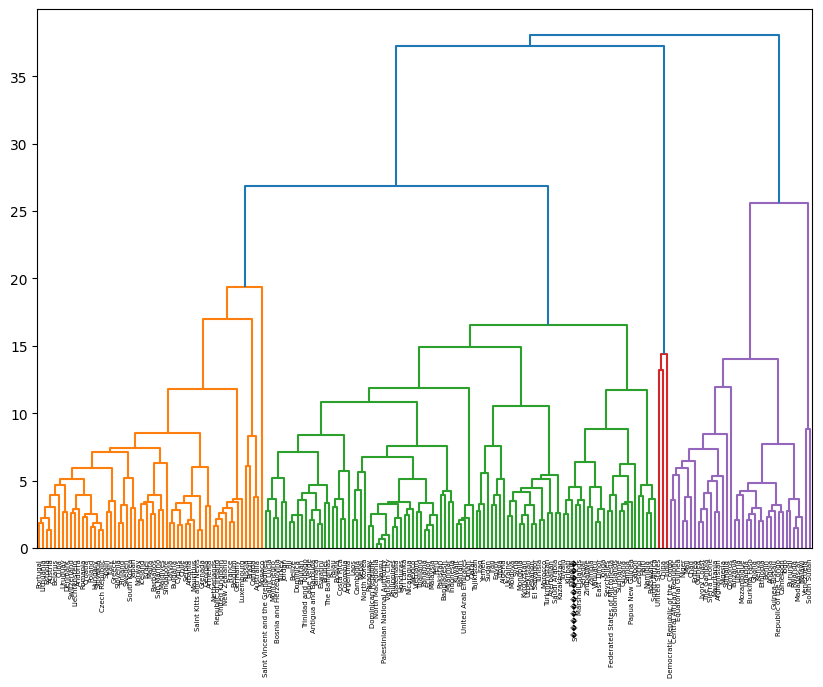

In [118]:
#Creating dendrogram with country name labels
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
linked = linkage(data_imputed, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=data['Country'].values,
            distance_sort='descending',
            show_leaf_counts=False)
plt.show()

In [119]:
#Understanding the clustering distribution with fcluster from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linked, t=4, criterion='maxclust')
# Adding these cluster assignments to the dataframe
data['Cluster_4'] = clusters
#grouping the data by cluster to see mean feature values per cluster
mean_features_4 = data.groupby('Cluster_4').mean(numeric_only=True)
mean_features_4

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
Cluster_4,,,,,,,,,,,,,,,,,,,,,
1,110.527778,49.877143,5.468018e+05,6.080000e+04,35.257778,1.306717e+04,376.029118,18.205882,4.721389,28.677143,...,533.611111,0.364138,42.168571,0.177714,2.817165e+07,68.375000,10.363333,55.160000,4.922500,1.122447e+07
2,217.666667,53.666667,7.572580e+06,2.361667e+06,13.453333,5.769004e+06,140.920000,6.033333,1.880000,26.700000,...,64.333333,2.806667,36.200000,1.816667,1.030791e+09,59.766667,10.066667,48.500000,8.126667,5.282095e+08
3,186.444444,36.185106,4.170201e+05,1.455488e+05,20.549570,7.513997e+04,162.627191,5.242697,2.605161,33.314894,...,99.855556,1.229733,31.967368,1.325638,2.372770e+07,61.577907,16.696386,36.970330,7.965814,1.363010e+07
4,815.421053,36.535714,8.862554e+05,1.193725e+05,10.524211,1.561031e+05,119.624615,1.879245,1.595714,32.205357,...,12.326923,5.067674,27.534545,3.743036,2.119438e+07,60.890196,20.266038,37.594444,6.379412,1.698113e+07


In [ ]:
print(mean_features_4.columns)

Index(['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
       'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI',
       'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Life expectancy', 'Maternal mortality ratio', 'Minimum wage',
       'Out of pocket health expenditure', 'Physicians per thousand',
       'Population', 'Population: Labor force participation (%)',
       'Tax revenue (%)', 'Total tax rate', 'Unemployment rate',
       'Urban_population'],
      dtype='object')


In [ ]:
#The Cluster_4 has gone a set down in dataframe fix it
mean_features_4 = mean_features_4.reset_index()


In [122]:
#Exporting the data with cluster labels
mean_features_4

,Cluster_4,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,1,110.527778,49.877143,5.468018e+05,6.080000e+04,35.257778,1.306717e+04,376.029118,18.205882,4.721389,...,533.611111,0.364138,42.168571,0.177714,2.817165e+07,68.375000,10.363333,55.160000,4.922500,1.122447e+07
1,2,217.666667,53.666667,7.572580e+06,2.361667e+06,13.453333,5.769004e+06,140.920000,6.033333,1.880000,...,64.333333,2.806667,36.200000,1.816667,1.030791e+09,59.766667,10.066667,48.500000,8.126667,5.282095e+08
2,3,186.444444,36.185106,4.170201e+05,1.455488e+05,20.549570,7.513997e+04,162.627191,5.242697,2.605161,...,99.855556,1.229733,31.967368,1.325638,2.372770e+07,61.577907,16.696386,36.970330,7.965814,1.363010e+07
3,4,815.421053,36.535714,8.862554e+05,1.193725e+05,10.524211,1.561031e+05,119.624615,1.879245,1.595714,...,12.326923,5.067674,27.534545,3.743036,2.119438e+07,60.890196,20.266038,37.594444,6.379412,1.698113e+07


In [126]:
mean_features_4.to_csv('country_clusters.csv',index=False)

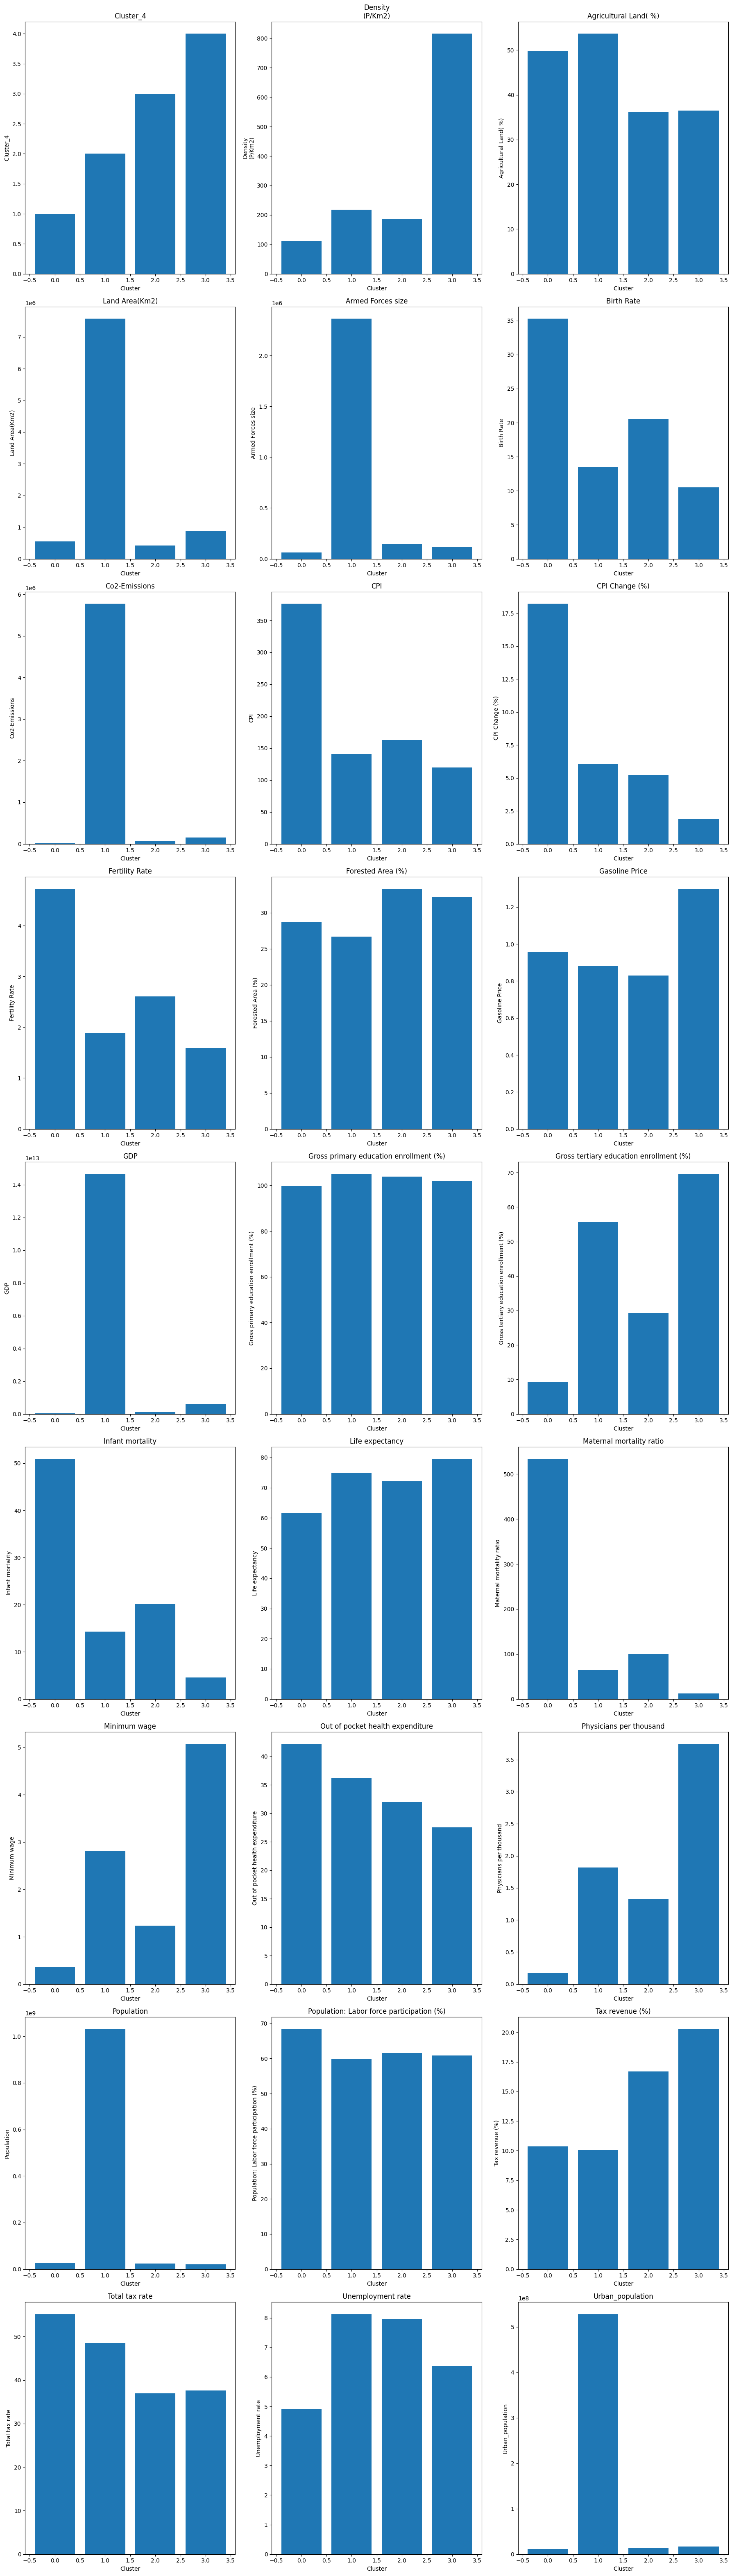

In [123]:
import math
import matplotlib.pyplot as plt

cols = mean_features_4.columns
n_cols = 3                         # number of plots per row
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(6 * n_cols, 7 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.bar(mean_features_4.index, mean_features_4[col])
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [124]:
data

,Country,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Cluster_4
0,Afghanistan,60.0,58.1,652230.0,323000.0,32.49,8672.0,149.90,2.3,4.47,...,0.43,78.4,0.28,38041754.0,48.9,9.3,71.4,11.12,9797273.0,1
1,Albania,105.0,43.1,28748.0,9000.0,11.78,4536.0,119.05,1.4,1.62,...,1.12,56.9,1.20,2854191.0,55.7,18.6,36.6,12.33,1747593.0,4
2,Algeria,18.0,17.4,2381741.0,317000.0,24.28,150006.0,151.36,2.0,3.02,...,0.95,28.1,1.72,43053054.0,41.2,37.2,66.1,11.70,31510100.0,3
3,Andorra,164.0,40.0,468.0,NaN,7.20,469.0,NaN,NaN,1.27,...,6.63,36.4,3.33,77142.0,NaN,NaN,NaN,NaN,67873.0,4
4,Angola,26.0,47.5,1246700.0,117000.0,40.73,34693.0,261.73,17.1,5.52,...,0.71,33.4,0.21,31825295.0,77.5,9.2,49.1,6.89,21061025.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32.0,24.5,912050.0,343000.0,17.88,164175.0,2740.27,254.9,2.27,...,0.01,45.8,1.92,28515829.0,59.7,NaN,73.3,8.80,25162368.0,1
191,Vietnam,314.0,39.3,331210.0,522000.0,16.75,192668.0,163.52,2.8,2.05,...,0.73,43.5,0.82,96462106.0,77.4,19.1,37.6,2.01,35332140.0,3
192,Yemen,56.0,44.6,527968.0,40000.0,30.45,10609.0,157.58,8.1,3.79,...,NaN,81.0,0.31,29161922.0,38.0,NaN,26.6,12.91,10869523.0,3
193,Zambia,25.0,32.1,752618.0,16000.0,36.19,5141.0,212.31,9.2,4.63,...,0.24,27.5,1.19,17861030.0,74.6,16.2,15.6,11.43,7871713.0,3


In [127]:
data['Cluster_4'].value_counts()

Cluster_4
3    99
4    57
1    36
2     3
Name: count, dtype: int64

In [129]:
data_imputed['Cluster_4'] = clusters

In [131]:
#Creating country column in data_imputed data_imputed['Country'] = data['Country']
data_imputed['Country'] = data['Country']

In [132]:
data_imputed

,Density,Agricultural_Land,Land_Area,Armed_Forces_size,Birth_Rate,Co2_Emissions,CPI,CPI_Change,Fertility_Rate,Forested_Area,...,Out_of_pocket_health_expenditure,Physicians_per_thousand,Population,Population_Labor_force_participation,Tax_revenue,Total_tax_rate,Unemployment_rate,Urban_population,Cluster_4,Country
0,-0.150048,0.873759,-0.019510,4.314071e-01,1.237473,-0.202171,-1.022129e-01,-1.813773e-01,1.385509,-1.260766,...,2.393245,-0.928600,-0.009255,-1.321306e+00,-1.047970e+00,1.491487e+00,8.358997e-01,-0.166250,1,Afghanistan
1,-0.127295,0.183311,-0.344808,-3.959663e-01,-0.850349,-0.207115,-1.799544e-01,-2.182898e-01,-0.843051,-0.165013,...,1.268864,-0.380908,-0.252401,-6.720185e-01,2.918937e-01,-2.059567e-01,1.074805e+00,-0.273248,4,Albania
2,-0.171283,-0.999655,0.882851,4.155975e-01,0.409805,-0.033223,-9.853377e-02,-1.936815e-01,0.251680,-1.315554,...,-0.237283,-0.071343,0.025373,-2.056528e+00,2.971621e+00,1.232968e+00,9.504163e-01,0.122363,3,Algeria
3,-0.097464,0.040619,-0.359563,4.577235e-17,-1.312069,-0.211976,-2.993860e-17,1.984756e-17,-1.116734,0.083639,...,0.196781,0.887118,-0.271590,2.788174e-16,7.587619e-17,1.650168e-16,-8.326673e-17,-0.295576,4,Andorra
4,-0.167239,0.385843,0.290651,-1.113920e-01,2.068166,-0.171066,1.795968e-01,4.256273e-01,2.206557,0.602014,...,0.039890,-0.970273,-0.052211,1.409519e+00,-1.062377e+00,4.037573e-01,7.179726e-04,-0.016529,1,Angola
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,-0.164205,-0.672844,0.116049,4.841061e-01,-0.235394,-0.016286,6.425477e+00,1.017872e+01,-0.334783,0.871738,...,0.688370,0.047720,-0.075079,-2.900850e-01,7.587619e-17,1.584163e+00,3.778331e-01,0.037987,1,Venezuela
191,-0.021622,0.008398,-0.187000,9.557617e-01,-0.349312,0.017774,-6.789077e-02,-1.608704e-01,-0.506812,0.677874,...,0.568088,-0.607129,0.394429,1.399971e+00,3.639294e-01,-1.571796e-01,-9.628013e-01,0.173166,3,Vietnam
192,-0.152070,0.252356,-0.084343,-3.142830e-01,1.031816,-0.199855,-8.285947e-02,5.650285e-02,0.853782,-1.307125,...,2.529217,-0.910741,-0.070615,-2.362074e+00,7.587619e-17,-6.937279e-01,1.189322e+00,-0.151997,3,Yemen
193,-0.167744,-0.323017,0.032867,-3.775217e-01,1.610479,-0.206392,5.505924e-02,1.016181e-01,1.510621,1.398542,...,-0.268661,-0.386861,-0.148704,1.132617e+00,-5.387757e-02,-1.230276e+00,8.971068e-01,-0.191845,3,Zambia


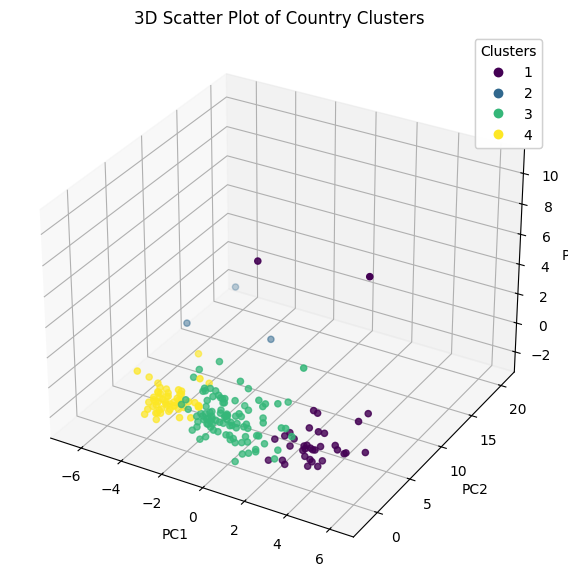

In [133]:
#using pca to reduce dimensions for visualization in 3d and then using seaborn to plot 3d scatter plot 
from sklearn.decomposition import PCA
import seaborn as sns
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_imputed.drop(['Country','Cluster_4'],axis=1))
data_pca = pd.DataFrame(data_pca,columns=['PC1','PC2','PC3'])
data_pca['Cluster_4'] = data_imputed['Cluster_4']
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_pca['PC1'], data_pca['PC2'], data_pca['PC3'], c=data_pca['Cluster_4'], cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('3D Scatter Plot of Country Clusters')
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()

In [135]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
import plotly.io as pio
pio.renderers.default = "browser"

# PCA to reduce to 3 components
pca = PCA(n_components=3)
data_pca = pca.fit_transform(
    data_imputed.drop(['Country', 'Cluster_4'], axis=1)
)

# Create DataFrame
data_pca = pd.DataFrame(
    data_pca,
    columns=['PC1', 'PC2', 'PC3']
)

# Add cluster and country info for coloring & hover
data_pca['Cluster_4'] = data_imputed['Cluster_4']
data_pca['Country'] = data_imputed['Country']

# Plotly 3D scatter
fig = px.scatter_3d(
    data_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster_4',
    hover_name='Country',
    title='3D Scatter Plot of Country Clusters (PCA)',
    color_continuous_scale='Viridis'
)

# Improve layout (optional but recommended)
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend_title_text='Clusters'
)

fig.show()

In [138]:
data_pca[data_imputed['Country'] == 'Nepal']

,PC1,PC2,PC3,Cluster_4,Country
121,0.793174,-0.306626,-1.433838,3,Nepal
